# ART calculations for `Ebola` virus (Ebola + Zaire Ebola)

### Training data base `Pubchem + chEMBL`

In [14]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
sys.path.append('.')   # Add local directory to access some of the functions
sys.path.append('../../') # Make sure this is the location for the ART library

import warning_utils
warning_utils.filter_end_user_warnings()

! pip install rdkit

In [58]:
import pandas as pd
import numpy as np
from rdkit import Chem

from art.core import RecommendationEngine
import art.utility as utils
import pickle
import cloudpickle
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import gc
import umap

### Define directories

In [16]:
dataDir = '/code/DTRA_ART/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
artResultDir = resultsDir + 'ART_results/Ebola_bestMACAW_allDB/'
os.makedirs(artResultDir, exist_ok=True)
saveDir = os.path.join(resultsDir, "combinedEbolaVirus_bestMACAW_allDB/")
os.makedirs(saveDir, exist_ok=True)

### Extract the data for `Ebola` into a data frame with `duplicate` SMILES

In [17]:
combinedEbolaVirusData_allDB_wMACAW = pd.read_csv(modelBuildingDataDir + "combinedEbolaVirusData_allDB_wMACAW.csv")
combinedEbolaVirusData_allDB_wMACAW 

,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category,MACAW_1,MACAW_2,MACAW_3,MACAW_4,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,1,12187083,Nc1ncnc2c1ncn2C1=C[C@H](CO)[C@@H](O)[C@H]1O,6.420216,Ebola,3-10,-0.240288,0.062063,-0.230976,0.279901,...,-0.019963,0.000519,-0.092109,-0.010635,0.017397,-0.007364,0.000245,-0.029113,-0.026589,0.034815
1,2,118714010,Nc1ncnc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.119186,Ebola,3-10,-0.240288,0.062063,-0.230976,0.279901,...,-0.019963,0.000519,-0.092109,-0.010635,0.017397,-0.007364,0.000245,-0.029113,-0.026589,0.034815
2,3,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,6.494850,Ebola,3-10,-0.221628,0.055945,-0.187033,0.257284,...,-0.020341,0.023101,-0.065631,0.011653,-0.002935,0.001612,-0.006218,0.005434,-0.037251,0.019134
3,4,66552950,Nc1ncc(Br)c2c1ncn2[C@@H]1C=C(CO)[C@@H](O)[C@H]1O,5.519993,Ebola,3-10,-0.221628,0.055945,-0.187033,0.257284,...,-0.020341,0.023101,-0.065631,0.011653,-0.002935,0.001612,-0.006218,0.005434,-0.037251,0.019134
4,5,118895044,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,3-10,-0.245631,0.070664,-0.222119,0.284871,...,-0.017031,0.014901,-0.079692,-0.014622,0.011341,-0.010857,-0.000649,-0.010641,-0.030644,0.032333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1950,1951,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,3-10,0.024561,0.025550,0.102400,0.028026,...,0.051293,0.040116,-0.022479,-0.071960,-0.062641,-0.009583,0.024917,-0.104851,-0.015794,0.011291
1951,1952,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997,ZaireEbola,3-10,0.024561,0.025550,0.102400,0.028026,...,0.051293,0.040116,-0.022479,-0.071960,-0.062641,-0.009583,0.024917,-0.104851,-0.015794,0.011291
1952,1953,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,3-10,-0.026562,0.033142,0.117421,0.032510,...,0.023438,-0.047451,0.033985,0.020067,0.041170,-0.031006,0.005918,-0.012591,-0.007155,-0.002364
1953,1954,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246,ZaireEbola,3-10,-0.026562,0.033142,0.117421,0.032510,...,0.023438,-0.047451,0.033985,0.020067,0.041170,-0.031006,0.005918,-0.012591,-0.007155,-0.002364


### Prepare data to run `ART` on `Ebola` data with `duplicate` SMILES

#### Find Features and Response

In [18]:
input_var = [col for col in combinedEbolaVirusData_allDB_wMACAW.columns if col.startswith('MACAW_')]
print(f"MACAW Embeddings: {len(input_var)}")
print(input_var)

MACAW Embeddings: 45
['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45']


In [19]:
features = combinedEbolaVirusData_allDB_wMACAW[input_var].to_numpy()

In [20]:
response_var = ["pPotency"]
print(response_var)

['pPotency']


In [21]:
response = combinedEbolaVirusData_allDB_wMACAW[response_var].to_numpy()

### save the data as a EDD style file

In [22]:
utils.save_edd_csv(features, response, input_var, modelBuildingDataDir + 'combinedEbolaVirusData_allDB_wMACAW_ARTready.csv', response_var)

### Predict response with ART

In [23]:
combinedEbolaVirusData_allDB_wMACAW_ARTready = pd.read_csv(modelBuildingDataDir + "combinedEbolaVirusData_allDB_wMACAW_ARTready.csv")
combinedEbolaVirusData_allDB_wMACAW_ARTready

,Line Name,Type,0.0
0,0,MACAW_1,-0.240288
1,1,MACAW_1,-0.240288
2,2,MACAW_1,-0.221628
3,3,MACAW_1,-0.221628
4,4,MACAW_1,-0.245631
...,...,...,...
89925,1950,pPotency,6.283997
89926,1951,pPotency,6.283997
89927,1952,pPotency,5.721246
89928,1953,pPotency,5.721246


### Define the ART parameters needed for the prediction

In [24]:
art_params = {
    'input_vars': input_var,
    'response_vars': response_var,
    'objective': 'maximize',
    'threshold': 0.2,
    'alpha': 0.5,
    'num_recommendations': 10,
    'max_mcmc_cores': 4,
    'seed': 42,                    
    'output_dir': artResultDir,
    'recommend': False,
    'cross_val': True,
    'num_tpot_models': 2,
}

### Run ART without recommendations but with cross-validations to gauge how generalizable the results are

ART identified 1,955 unique designs in the training data. 
Correctly communicating your designs is critical to building ART's model and to cross-validation.  We strongly suggest verifying ART's interpretation of your designs by inspecting the preprocessed DataFrame.  For example, if your ART instance is named `engine`, run `engine.df["Design"]`.  See Data Preparation docs for a description of how ART infers design information. https://lbl-biosci.gitlab.io/ese/art/Data_Preparation/#labeling-lines-designs-replicates-oh-my
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_regressor
is_regressor
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_regressor
is_regressor
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_regressor
is_regressor
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_regressor
is_regressor
is_regressor
is_classifier
is_classifier
is_classifier


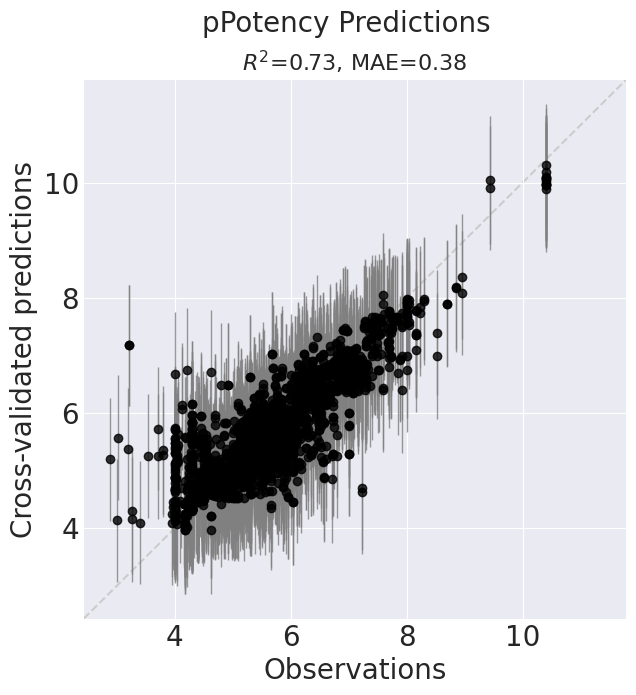

is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
i

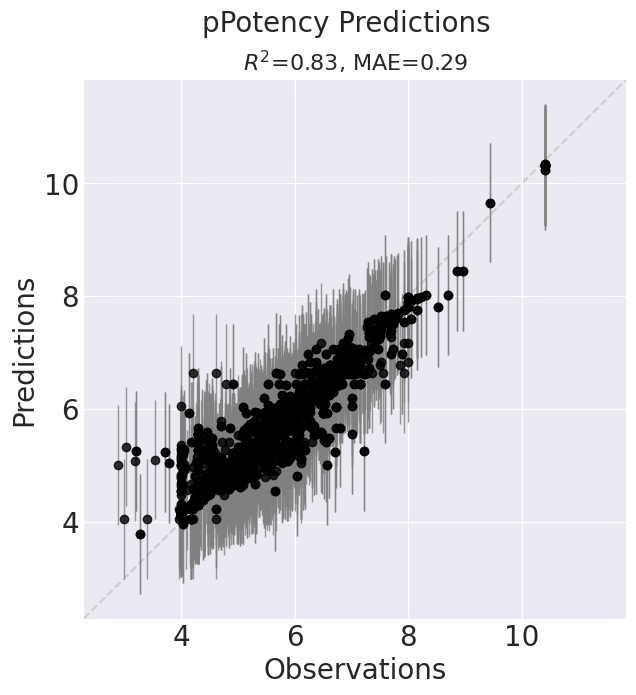

CPU times: user 3h 47min 54s, sys: 1min 10s, total: 3h 49min 5s
Wall time: 1d 5h 30min 47s


In [25]:
%%time

art = RecommendationEngine(df=combinedEbolaVirusData_allDB_wMACAW_ARTready, **art_params)

### Find SHAP values

We will now find which input features are more important by using SHAP analysis. First, lets initialize the library:

define a wrapper function that provides the ART prediction given and input X, for use by the SHAP library

convert the ART input data into the pandas dataframe that the SHAP library favors

create and execute the explainer for the features values

### Load pre-trained ART model (if necessary, otherwise skip this step)

In [26]:
ARTtrainedModelFile = os.path.join(artResultDir, 'art.cpkl')
with open(ARTtrainedModelFile, 'rb') as f:
    art = cloudpickle.load(f)
print(f" ART model loaded from: {ARTtrainedModelFile}")

 ART model loaded from: /code/DTRA_ART/DrugDesignData/Results/ART_results/Ebola_bestMACAW_allDB/art.cpkl


### Find external validation with pre-trained `ART` models

In [37]:
combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW = pd.read_csv(modelBuildingDataDir + "/Ebola_all_Buyable_AntiVirals_wMACAW.csv")

print(f"Total buyable antiviral molecules before removing training set molecules: {len(combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW)}")

# Get the set of training SMILES from the chEMBL data for fast lookup
training_smiles_set = set(combinedEbolaVirusData_allDB_wMACAW['Smiles'])

# Remove rows whose SMILES are present in the training data
combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW = combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW[
    ~combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW['SMILES'].isin(training_smiles_set)
].reset_index(drop=True)

removed_count = len(training_smiles_set) - (len(training_smiles_set) - (len(combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW)))
print(f"Training set molecules found and removed: {len(pd.read_csv(modelBuildingDataDir + '/Ebola_all_Buyable_AntiVirals_wMACAW.csv')) - len(combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW)}")
print(f"Total buyable antiviral molecules for external validation after removing training set molecules: {len(combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW)}")

combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW

Total buyable antiviral molecules before removing training set molecules: 113184
Training set molecules found and removed: 0
Total buyable antiviral molecules for external validation after removing training set molecules: 113184


,SMILES,source_DataBase,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals,-0.069875,0.152002,-0.028341,-0.022750,-0.046659,-0.022943,0.030823,-0.014035,...,-0.004912,-0.020892,0.005602,0.033271,0.012341,-0.003814,0.018443,-0.008985,0.018341,0.018395
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals,-0.066748,0.119139,0.027809,0.023615,-0.018260,-0.041816,0.031775,0.041994,...,-0.005174,-0.031375,0.000302,0.062174,0.019728,0.017627,-0.028755,0.014760,-0.026941,0.032282
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals,-0.025246,0.094025,0.100549,-0.033359,-0.011832,0.020565,0.024162,-0.029713,...,-0.038296,-0.030732,-0.001136,0.033778,-0.015746,-0.005701,-0.001416,-0.023764,0.005143,0.030657
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals,-0.022539,0.140361,0.076222,-0.067088,-0.026177,0.016590,0.023780,0.001185,...,-0.005779,-0.034909,-0.002715,0.062666,0.025507,0.004202,0.023097,0.009545,-0.058843,-0.032707
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals,-0.023909,0.081113,0.094601,-0.021425,0.041581,-0.020960,0.012028,0.000159,...,0.001873,-0.047648,-0.011862,0.049546,0.034467,0.004154,-0.012453,0.014072,-0.020983,-0.022132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113179,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals,0.040241,-0.050332,-0.047387,-0.007975,-0.082754,-0.012244,0.034773,-0.064674,...,-0.028432,-0.020902,-0.006730,0.006883,-0.008357,-0.039126,-0.000032,0.031431,-0.005441,0.031386
113180,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals,0.016940,-0.050276,-0.032967,0.022293,-0.088697,-0.006890,0.037141,-0.065805,...,-0.044079,-0.033439,-0.032830,0.029083,-0.002626,-0.032138,-0.011649,0.009173,0.007168,0.047497
113181,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals,0.013463,-0.025070,-0.028534,0.007611,-0.084735,0.003683,0.026565,-0.059489,...,-0.043543,-0.028724,-0.032869,0.043384,-0.002522,-0.037265,0.006432,0.005072,0.020985,0.022158
113182,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals,-0.018811,-0.015656,-0.120868,-0.019349,-0.058226,-0.081719,0.049818,-0.105713,...,-0.024613,-0.012775,0.003640,-0.039968,-0.013958,0.000731,0.001322,0.016990,-0.005247,0.017959


In [38]:
macaw_columns = [col for col in combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [40]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smiLib)

# Now use these for your results
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction = combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW[['SMILES', 'source_DataBase']].copy()

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_prediction'] = mean
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_upper_95CI'])
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction['pPotency_lower_95CI'])

# Select and save results
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction = combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.filter(
    items=["SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.to_csv(os.path.join(saveDir + "/combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction.csv"), index=False)
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction[['SMILES']].to_csv(os.path.join(saveDir + "/combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction

Predictions saved with uncertainty estimates


,SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals,5.427234,0.541357,4.366175,6.488293,0.000004,3.248682e-07,0.000043
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals,5.497968,0.541794,4.436052,6.559884,0.000003,2.754964e-07,0.000037
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals,5.451149,0.541491,4.389826,6.512471,0.000004,3.072762e-07,0.000041
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals,5.348337,0.542093,4.285835,6.410840,0.000004,3.882937e-07,0.000052
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals,5.549473,0.541441,4.488248,6.610698,0.000003,2.450769e-07,0.000032
...,...,...,...,...,...,...,...,...,...
113179,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals,5.879166,0.541892,4.817057,6.941274,0.000001,1.144790e-07,0.000015
113180,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals,5.649842,0.543034,4.585496,6.714189,0.000002,1.931128e-07,0.000026
113181,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals,5.659090,0.541734,4.597291,6.720888,0.000002,1.901569e-07,0.000025
113182,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals,5.669463,0.542205,4.606741,6.732186,0.000002,1.852739e-07,0.000025


### Plot prediction probability

Molecule 1: mean=6.235, std=0.544, 95% CI=[5.152, 7.306], IC50=0.5816 µM
Molecule 2: mean=6.161, std=0.550, 95% CI=[5.087, 7.244], IC50=0.6910 µM
Molecule 3: mean=6.146, std=0.549, 95% CI=[5.061, 7.201], IC50=0.7138 µM
Molecule 4: mean=6.126, std=0.538, 95% CI=[5.045, 7.161], IC50=0.7487 µM
Molecule 5: mean=6.115, std=0.546, 95% CI=[5.052, 7.202], IC50=0.7670 µM
Molecule 6: mean=6.123, std=0.556, 95% CI=[5.035, 7.208], IC50=0.7539 µM
Molecule 7: mean=6.116, std=0.546, 95% CI=[5.035, 7.182], IC50=0.7663 µM
Molecule 8: mean=6.105, std=0.548, 95% CI=[5.040, 7.171], IC50=0.7860 µM
Molecule 9: mean=6.116, std=0.536, 95% CI=[5.059, 7.178], IC50=0.7651 µM
Molecule 10: mean=6.090, std=0.553, 95% CI=[5.029, 7.179], IC50=0.8123 µM
Molecule 11: mean=6.098, std=0.545, 95% CI=[5.034, 7.247], IC50=0.7983 µM
Molecule 12: mean=6.115, std=0.531, 95% CI=[5.055, 7.142], IC50=0.7675 µM
Molecule 13: mean=6.102, std=0.546, 95% CI=[5.053, 7.196], IC50=0.7905 µM
Molecule 14: mean=6.093, std=0.542, 95% CI=[5.0

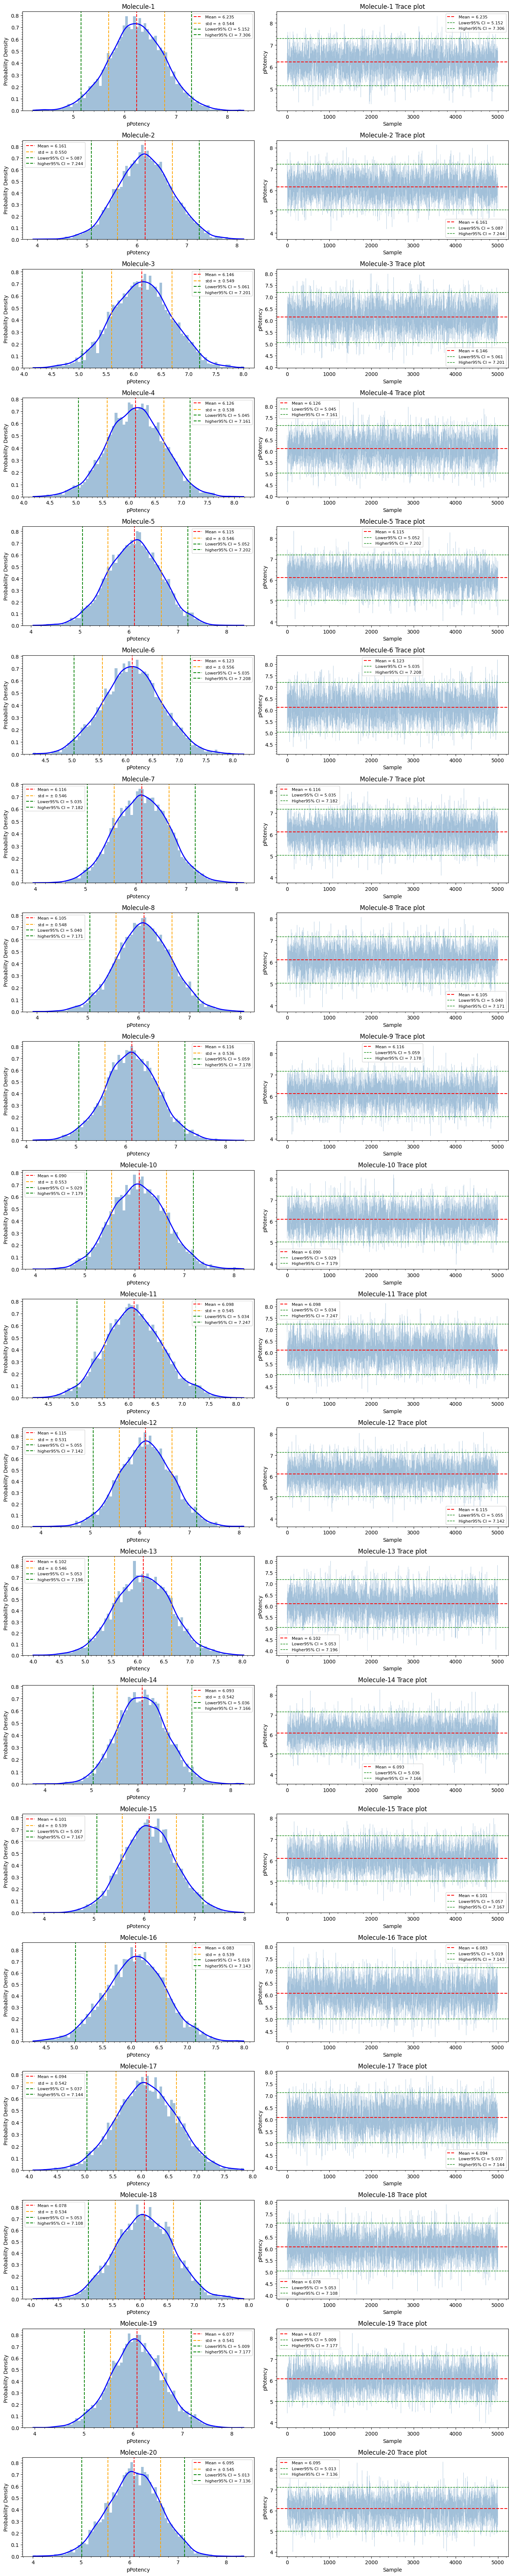

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['SMILES', *macaw_cols]], on='SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction,
    feat_df=combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)

### Rank molecules by `best probability`

- SMILES: the molecule identifier.
- P(pPotency>=4): estimated as
$$\frac{\#\{\text{posterior draws }\ge 4\}}{n\_samples}$$
(0.93 means 93% of posterior predictive samples are ≥ 4)
- post_mean: average of posterior draws (Bayesian estimate of expected pPotency).
- post_std: spread of posterior draws (predictive uncertainty).
- post_q05 / post_q95 (or 2.5/97.5): predictive interval quantiles.




In [47]:
def rankByProbGeThreshold(predDf, featDf, art, threshold=4.0,
                          topN=20, nSamples=5000, candidatePool=None):
    macawCols = [c for c in featDf.columns if c.startswith("MACAW_")]

    # Choose how many molecules to evaluate (all if candidatePool is None)
    if candidatePool is None:
        candDf = predDf.copy()
    else:
        candDf = (
            predDf.sort_values("pPotency_prediction", ascending=False)
                  .head(candidatePool)
                  .copy()
        )

    # Include source_DataBase if present in predDf
    baseCols = ["SMILES", "pPotency_prediction"]
    if "source_DataBase" in candDf.columns:
        baseCols.insert(1, "source_DataBase")  # keep it next to SMILES

    mergedDf = (
        candDf[baseCols]
        .merge(featDf[["SMILES", *macawCols]], on="SMILES", how="inner")
        .drop_duplicates("SMILES")
        .reset_index(drop=True)
    )
    if mergedDf.empty:
        raise ValueError("No molecules matched between predDf and featDf on SMILES.")

    probs = []
    postMeans = []
    postStds = []
    q05s = []
    q95s = []

    for _, row in mergedDf.iterrows():
        x = row[macawCols].to_numpy(dtype=float).reshape(1, -1)
        draws = np.asarray(art.post_pred_draws(x, n_samples=nSamples)).ravel()

        probs.append(np.mean(draws >= threshold))
        postMeans.append(draws.mean())
        postStds.append(draws.std(ddof=1))
        q05, q95 = np.percentile(draws, [5, 95])
        q05s.append(q05)
        q95s.append(q95)

    rankedDf = mergedDf[baseCols].copy()
    rankedDf["probPotencyGeThreshold"] = probs
    rankedDf["postMean"] = postMeans
    rankedDf["postStd"]  = postStds
    rankedDf["postQ05"]  = q05s
    rankedDf["postQ95"]  = q95s

    rankedDf = rankedDf.sort_values(
        ["probPotencyGeThreshold", "postMean"],
        ascending=[False, False]
    )
    return rankedDf.head(topN).reset_index(drop=True)

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability_top20 = rankByProbGeThreshold(
    predDf=combinedEbolaVirus_all_Buyable_AntiVirals_ARTprediction,
    featDf=combinedEbolaVirus_all_Buyable_AntiVirals_wMACAW,
    art=art,
    threshold=5.0,
    topN=20,
    nSamples=5000,
    candidatePool=500
)

combinedEbolaVirus_all_Buyable_AntiVirals_ARTprobability_top20

,SMILES,source_DataBase,pPotency_prediction,probPotencyGeThreshold,postMean,postStd,postQ05,postQ95
0,CCOC(=O)c1c(CN2CCCCC2)n(-c2ccccc2)c2cc(Br)c(O)...,ChemDiv_Antivirals,6.235568,0.9886,6.240458,0.540135,5.350956,7.123702
1,CCOC(=O)c1c(NC(=O)CSc2nc3c(cnn3-c3ccc(C)c(C)c3...,ChemDiv_Antivirals,6.127619,0.9826,6.139192,0.544086,5.252762,7.028720
2,CCOC(=O)c1c(NC(=O)CSc2nc3c(cnn3-c3ccc(C)cc3)c(...,ChemDiv_Antivirals,6.158409,0.9820,6.139722,0.531216,5.282752,6.999901
3,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,LifeChemicals_Antivirals,6.114496,0.9818,6.121225,0.544555,5.228232,7.032612
4,CCOC(=O)c1nn(-c2cccc(Cl)c2)c(=O)c2c(NC(=O)c3cc...,LifeChemicals_Antivirals,6.110043,0.9812,6.113724,0.534113,5.238343,6.995272
5,CCOC(=O)c1c(NC(=O)CSc2nc3c(cnn3-c3ccc(C)cc3)c(...,ChemDiv_Antivirals,6.144010,0.9806,6.140194,0.547243,5.243007,7.051634
6,CCCN1CCN(CCCNC(=O)Cn2c(=O)c(=O)n(CC)c3ccccc32)CC1,ChemDiv_Antivirals,6.117096,0.9800,6.123105,0.543638,5.237627,7.013296
7,O=C(c1ccc2c(c1)OCO2)N1CCC(c2nc(O)c3nnn(Cc4ccc(...,ChemDiv_Antivirals,6.103949,0.9800,6.106447,0.542535,5.225556,7.008707
8,CCOC(=O)c1c(NC(=O)CSc2nc3c(cnn3-c3ccc(C)c(C)c3...,ChemDiv_Antivirals,6.103917,0.9800,6.100351,0.537869,5.229535,6.996167
9,CCOC(=O)c1c(NC(=O)CSc2nc3c(cnn3-c3ccc(C)cc3)c(...,ChemDiv_Antivirals,6.103369,0.9798,6.113295,0.544758,5.209695,7.019363


## `Inosine + Adenosine + Guanosine + Xanthosine`

Find external validation with pre-trained `ART` models for DORAnet generated molecules

In [30]:
def canonicalize(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol) if mol else smi

# Load DORAnet generated molecules
Ebola_allDORAnetGenerated_Antivirals_wMACAW = pd.read_csv(
    modelBuildingDataDir + "/Ebola_allDORAnetGenerated_Antivirals_wMACAW.csv"
)

total_before = len(Ebola_allDORAnetGenerated_Antivirals_wMACAW)
print(f"Total DORAnet generated molecules before removing training set molecules: {total_before}")

# Training set stats
total_training_rows = len(combinedEbolaVirusData_allDB_wMACAW)
unique_training_smiles = combinedEbolaVirusData_allDB_wMACAW['Smiles'].nunique()
duplicate_training_smiles = combinedEbolaVirusData_allDB_wMACAW['Smiles'].duplicated().sum()
print(f"Total training set SMILES: {total_training_rows}")
print(f"Unique training set SMILES: {unique_training_smiles}")
print(f"Duplicate training set SMILES: {duplicate_training_smiles}")

# Canonicalize training SMILES for consistent matching
training_smiles_set = set(combinedEbolaVirusData_allDB_wMACAW['Smiles'].apply(canonicalize))
print(f"Unique canonical training SMILES: {len(training_smiles_set)}")

# Canonicalize DORAnet SMILES and remove matches
Ebola_allDORAnetGenerated_Antivirals_wMACAW['canonical_SMILES'] = \
    Ebola_allDORAnetGenerated_Antivirals_wMACAW['SMILES'].apply(canonicalize)

Ebola_allDORAnetGenerated_Antivirals_wMACAW = \
    Ebola_allDORAnetGenerated_Antivirals_wMACAW[
        ~Ebola_allDORAnetGenerated_Antivirals_wMACAW['canonical_SMILES'].isin(training_smiles_set)
    ].drop(columns=['canonical_SMILES']).reset_index(drop=True)

total_after = len(Ebola_allDORAnetGenerated_Antivirals_wMACAW)
print(f"\nTraining set molecules found and removed: {total_before - total_after}")
print(f"Total DORAnet generated molecules for external validation: {total_after}")

Ebola_allDORAnetGenerated_Antivirals_wMACAW

Total DORAnet generated molecules before removing training set molecules: 20372
Total training set SMILES: 1955
Unique training set SMILES: 667
Duplicate training set SMILES: 1288
Unique canonical training SMILES: 667

Training set molecules found and removed: 0
Total DORAnet generated molecules for external validation: 20372


,SMILES,Is_Starter,SourceDirectories,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,-0.155672,0.121245,-0.158621,-0.245797,0.051937,-0.028502,0.041505,...,0.013639,0.023496,0.012767,-0.055034,0.002650,-0.009793,-0.029991,-0.003456,0.010401,0.009718
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,-0.062498,-0.001674,-0.172976,-0.085888,-0.027499,0.001712,0.004088,...,-0.017014,0.030871,-0.032103,-0.000645,-0.039020,-0.039074,0.011564,-0.014262,0.006201,0.002577
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,-0.122775,0.073886,-0.165282,-0.193546,0.015358,-0.008155,0.029555,...,-0.003453,0.022708,-0.005385,-0.013121,-0.011216,-0.018578,-0.002260,0.009511,-0.010791,0.005521
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,0.062059,-0.107636,-0.226905,0.009658,-0.051995,0.032107,-0.046871,...,-0.010044,0.016765,-0.009854,-0.017195,0.014200,0.009263,-0.006162,-0.015214,0.018113,-0.007897
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,0.072074,-0.114206,-0.218925,0.013373,-0.049576,0.031412,-0.051902,...,-0.005775,0.021132,-0.011059,-0.008376,0.015303,0.006186,-0.008786,-0.010408,0.021177,-0.005633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,-0.128243,0.087434,-0.142367,-0.176863,0.035721,-0.031132,0.016971,...,0.039390,0.035623,0.024196,-0.044297,-0.015711,-0.031388,-0.008565,-0.019521,0.009999,-0.002226
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,-0.103039,0.036266,-0.144871,-0.121718,0.006805,-0.030724,0.024553,...,0.032094,0.057337,0.032793,-0.027932,-0.018305,-0.005982,-0.000092,-0.013279,-0.007407,0.021191
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,-0.112166,0.036025,-0.145449,-0.112881,0.021942,-0.033107,0.022069,...,0.034117,0.061301,0.048715,-0.028282,-0.010216,-0.013702,0.002406,-0.008731,0.017373,0.002068
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,-0.125155,0.061587,-0.132723,-0.142053,0.017349,-0.018429,0.036769,...,0.030951,0.024619,0.023236,-0.027374,-0.004293,-0.009460,0.001579,-0.012756,0.008471,0.000209


In [31]:
macaw_columns = [col for col in Ebola_allDORAnetGenerated_Antivirals_wMACAW.columns if col.startswith('MACAW_')]
smiLib = Ebola_allDORAnetGenerated_Antivirals_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [35]:
chunk_size = 50000
total_rows = len(Ebola_allDORAnetGenerated_Antivirals_wMACAW)
print(f"Total molecules to predict: {total_rows}")
print(f"Processing in chunks of {chunk_size}...")

macaw_cols = [col for col in Ebola_allDORAnetGenerated_Antivirals_wMACAW.columns if col.startswith('MACAW_')]

output_path = os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv")
smiles_output_path = os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_ARTprediction_SMILESonly.csv")

if os.path.exists(output_path):
    os.remove(output_path)
if os.path.exists(smiles_output_path):
    os.remove(smiles_output_path)

header_written = False

for start in range(0, total_rows, chunk_size):
    end = min(start + chunk_size, total_rows)
    print(f"  Processing chunk {start} - {end} ({end}/{total_rows})...")

    chunk_features = Ebola_allDORAnetGenerated_Antivirals_wMACAW.iloc[start:end][macaw_cols].values
    chunk_smiles = Ebola_allDORAnetGenerated_Antivirals_wMACAW.iloc[start:end]['SMILES'].values
    chunk_is_starter = Ebola_allDORAnetGenerated_Antivirals_wMACAW.iloc[start:end]['Is_Starter'].values
    chunk_source_dirs = Ebola_allDORAnetGenerated_Antivirals_wMACAW.iloc[start:end]['SourceDirectories'].values

    mean, std = art.post_pred_stats(chunk_features)
    mean = np.array(mean).flatten()
    std = np.array(std).flatten()

    chunk_df = pd.DataFrame({
        'SMILES': chunk_smiles,
        'Is_Starter': chunk_is_starter,
        'SourceDirectories': chunk_source_dirs,
        'pPotency_prediction': mean,
        'pPotency_std': std,
        'pPotency_lower_95CI': mean - 1.96 * std,
        'pPotency_upper_95CI': mean + 1.96 * std,
        'IC50(M)_prediction': 10 ** (-mean),
        'IC50(M)_lower_95CI': 10 ** (-(mean + 1.96 * std)),
        'IC50(M)_upper_95CI': 10 ** (-(mean - 1.96 * std)),
    })

    chunk_df.to_csv(output_path, mode='a', header=not header_written, index=False)
    chunk_df[['SMILES']].to_csv(smiles_output_path, mode='a', header=not header_written, index=False)
    header_written = True

    del chunk_features, chunk_smiles, chunk_is_starter, chunk_source_dirs, mean, std, chunk_df
    gc.collect()

print(f"\nPredictions saved to: {output_path}")
print(f"SMILES-only saved to: {smiles_output_path}")

Ebola_allDORAnetGenerated_Antivirals_ARTprediction = pd.read_csv(output_path)
print(f"Total predictions: {len(Ebola_allDORAnetGenerated_Antivirals_ARTprediction)}")
Ebola_allDORAnetGenerated_Antivirals_ARTprediction

Total molecules to predict: 20372
Processing in chunks of 50000...
  Processing chunk 0 - 20372 (20372/20372)...

Predictions saved to: /code/DTRA_ART/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv
SMILES-only saved to: /code/DTRA_ART/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/Ebola_allDORAnetGenerated_Antivirals_ARTprediction_SMILESonly.csv
Total predictions: 20372


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.222995,0.542566,4.159566,6.286425,0.000006,5.171008e-07,0.000069
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.504085,0.542176,4.441421,6.566750,0.000003,2.711755e-07,0.000036
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.165484,0.541121,4.104888,6.226081,0.000007,5.941817e-07,0.000079
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.940053,0.542003,4.877728,7.002378,0.000001,9.945384e-08,0.000013
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.705785,0.541127,4.645176,6.766393,0.000002,1.712406e-07,0.000023
...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.096468,0.541756,4.034627,6.158309,0.000008,6.945304e-07,0.000092
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.495584,0.543710,4.429913,6.561255,0.000003,2.746279e-07,0.000037
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.195633,0.543232,4.130899,6.260367,0.000006,5.490765e-07,0.000074
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.149015,0.543289,4.084169,6.213862,0.000007,6.111364e-07,0.000082


Molecule 1: mean=5.929, std=0.549, 95% CI=[4.856, 6.995], IC50=1.1764 µM
Molecule 2: mean=5.804, std=0.552, 95% CI=[4.739, 6.894], IC50=1.5704 µM
Molecule 3: mean=5.785, std=0.543, 95% CI=[4.719, 6.844], IC50=1.6396 µM
Molecule 4: mean=5.807, std=0.543, 95% CI=[4.750, 6.880], IC50=1.5606 µM
Molecule 5: mean=5.780, std=0.539, 95% CI=[4.721, 6.837], IC50=1.6613 µM
Molecule 6: mean=5.762, std=0.534, 95% CI=[4.741, 6.809], IC50=1.7292 µM
Molecule 7: mean=5.697, std=0.541, 95% CI=[4.622, 6.749], IC50=2.0090 µM
Molecule 8: mean=5.676, std=0.541, 95% CI=[4.604, 6.721], IC50=2.1077 µM
Molecule 9: mean=5.670, std=0.541, 95% CI=[4.592, 6.726], IC50=2.1380 µM
Molecule 10: mean=5.660, std=0.539, 95% CI=[4.578, 6.686], IC50=2.1853 µM
Molecule 11: mean=5.666, std=0.548, 95% CI=[4.608, 6.740], IC50=2.1583 µM
Molecule 12: mean=5.656, std=0.549, 95% CI=[4.581, 6.739], IC50=2.2069 µM
Molecule 13: mean=5.643, std=0.547, 95% CI=[4.576, 6.707], IC50=2.2753 µM
Molecule 14: mean=5.659, std=0.551, 95% CI=[4.5

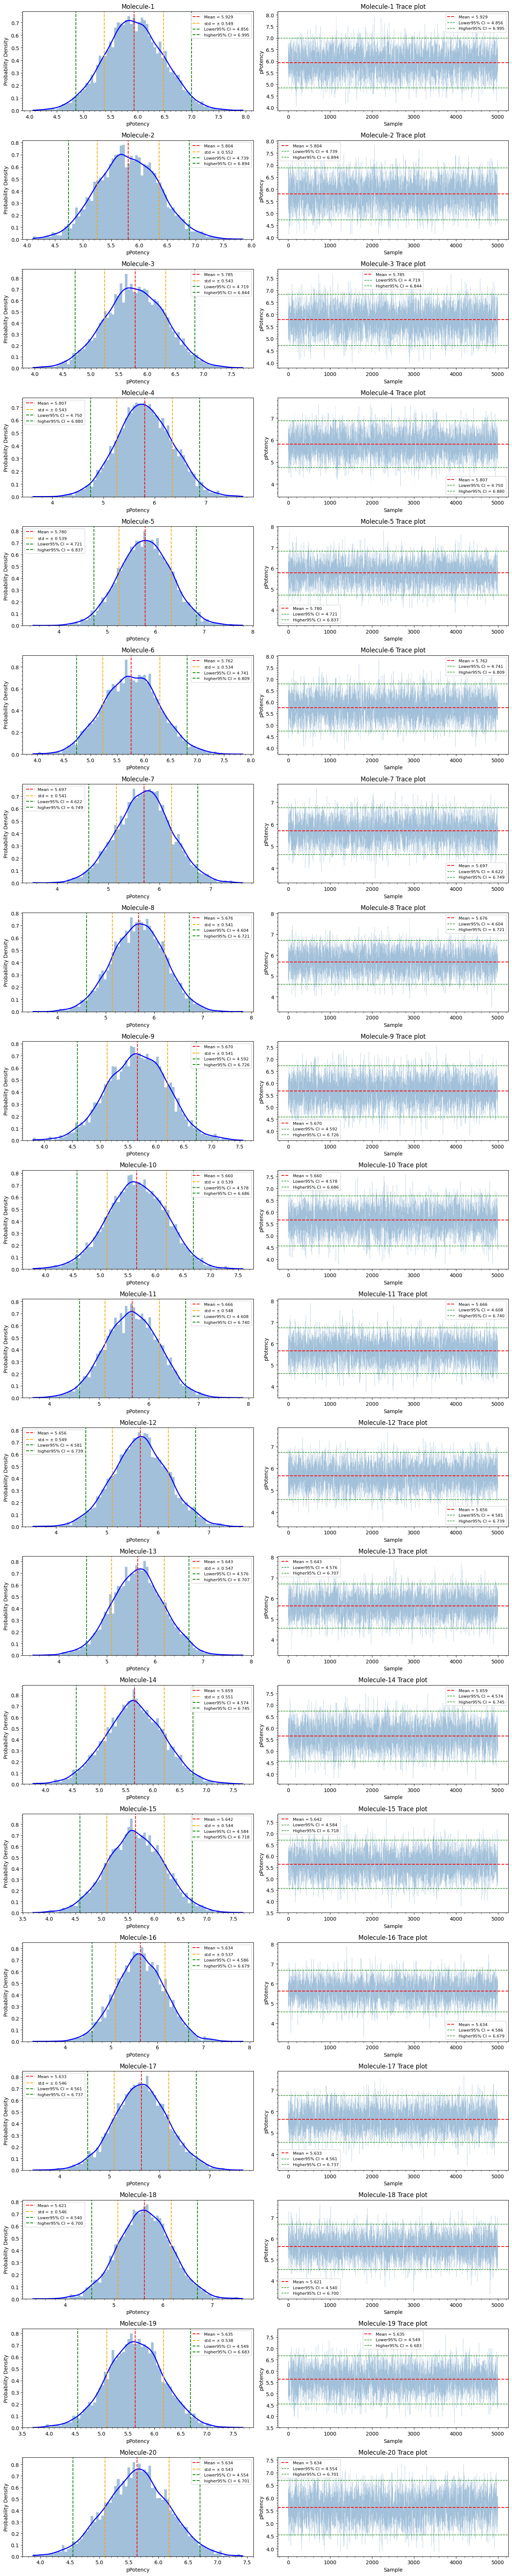

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['SMILES', *macaw_cols]], on='SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "Ebola_allDORAnetGenerated_Antivirals_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=Ebola_allDORAnetGenerated_Antivirals_ARTprediction,
    feat_df=Ebola_allDORAnetGenerated_Antivirals_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)

## `InosineSubstructures`: Find external validation with pre-trained `ART` models for DORAnet generated molecules

In [ ]:
combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW = pd.read_csv(modelBuildingDataDir + "/combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.csv")

total_before = len(combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW)
print(f"Total DORAnet generated molecules before removing training set molecules: {total_before}")

# Get the set of training SMILES from the chEMBL data for fast lookup
training_smiles_set = set(combinedEbolaVirusData_allDB_wMACAW['Smiles'])

# Remove rows whose SMILES are present in the training data
combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW = combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW[
    ~combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW['SMILES'].isin(training_smiles_set)
].reset_index(drop=True)

total_after = len(combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW)
print(f"Training set molecules found and removed: {total_before - total_after}")
print(f"Total DORAnet generated molecules for external validation: {total_after}")

combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW

In [ ]:
macaw_columns = [col for col in combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]
smiLib = combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW[macaw_columns].values

### Get predictions with uncertainty using ART's post_pred_stats

In [ ]:
# Process predictions in chunks
chunk_size = 100000
total_rows = len(combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW)
print(f"Total molecules to predict: {total_rows}")
print(f"Processing in chunks of {chunk_size}...")

# Prepare the MACAW feature columns
macaw_cols = [col for col in combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.columns if col.startswith('MACAW_')]

# Output paths
output_path = os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.csv")
smiles_output_path = os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction_SMILESonly.csv")

# Remove existing files to avoid appending to old results
if os.path.exists(output_path):
    os.remove(output_path)
if os.path.exists(smiles_output_path):
    os.remove(smiles_output_path)

header_written = False

for start in range(0, total_rows, chunk_size):
    end = min(start + chunk_size, total_rows)
    print(f"  Processing chunk {start} - {end} ({end}/{total_rows})...")

    # Extract chunk features
    chunk_features = combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.iloc[start:end][macaw_cols].values
    chunk_smiles = combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_wMACAW.iloc[start:end]['SMILES'].values

    # Get predictions for this chunk
    mean, std = art.post_pred_stats(chunk_features)

    # Flatten in case they are 2D arrays
    mean = np.array(mean).flatten()
    std = np.array(std).flatten()

    # Build chunk results
    chunk_df = pd.DataFrame({
        'SMILES': chunk_smiles,
        'pPotency_prediction': mean,
        'pPotency_std': std,
        'pPotency_lower_95CI': mean - 1.96 * std,
        'pPotency_upper_95CI': mean + 1.96 * std,
        'IC50(M)_prediction': 10 ** (-mean),
        'IC50(M)_lower_95CI': 10 ** (-(mean + 1.96 * std)),
        'IC50(M)_upper_95CI': 10 ** (-(mean - 1.96 * std)),
    })

    # Append to CSV
    chunk_df.to_csv(output_path, mode='a', header=not header_written, index=False)
    chunk_df[['SMILES']].to_csv(smiles_output_path, mode='a', header=not header_written, index=False)
    header_written = True

    # Free memory
    del chunk_features, chunk_smiles, mean, std, chunk_df
    gc.collect()

print(f"\nPredictions saved to: {output_path}")
print(f"SMILES-only saved to: {smiles_output_path}")

# Read back if needed for display
combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction = pd.read_csv(output_path)
print(f"Total predictions: {len(combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction)}")
combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.head()

### Plot the probability distribution

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['SMILES', *macaw_cols]], on='SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.2f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.2f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.2f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(saveDir, "combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction,
    feat_df=Ebola_allDORAnetGenerated_Antivirals_wMACAW,
    art=art,
    n=20,
    n_samples=5000
)

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

Load MACAW embeedings for external validation data set

In [ ]:
combinedEbolaVirus_EnamineDatasets_wMACAW = pd.read_csv(saveDir + "/combinedEbolaVirus_EnamineDatasets_wMACAW.csv")
combinedEbolaVirus_EnamineDatasets_wMACAW

In [ ]:
macaw_columns = [col for col in combinedEbolaVirus_EnamineDatasets_wMACAW.columns if col.startswith('MACAW_')]
smi_lib_EnamineDatasets_wMACAW = combinedEbolaVirus_EnamineDatasets_wMACAW[macaw_columns].values

In [ ]:
Y1_lib_pred = art.predict(smi_lib_EnamineDatasets_wMACAW)
Y1_lib_pred

Get predictions with uncertainty using ART's post_pred_stats

In [ ]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smi_lib_EnamineDatasets_wMACAW)

# Now use these for your results
EnamineAntiviralsData_predicted = combinedEbolaVirus_EnamineDatasets_wMACAW[['SMILES']].copy()
EnamineAntiviralsData_predicted['pPotency_prediction'] = mean
EnamineAntiviralsData_predicted['pPotency_std'] = std

# Calculate 95% Confidence Intervals
EnamineAntiviralsData_predicted['pPotency_lower_95CI'] = mean - 1.96 * std
EnamineAntiviralsData_predicted['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
EnamineAntiviralsData_predicted['IC50(M)_prediction'] = 10 ** (-mean)
EnamineAntiviralsData_predicted['IC50(M)_lower_95CI'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_upper_95CI'])
EnamineAntiviralsData_predicted['IC50(M)_upper_95CI'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_lower_95CI'])

# Select and save results
EnamineAntiviralsData_predicted = EnamineAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

EnamineAntiviralsData_predicted.to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_EnamineDataset_predicted_all.csv"), index=False)
EnamineAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_EnamineDataset_predicted_all_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
EnamineAntiviralsData_predicted

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
combinedEbolaVirus_LCAntiviralsData_wMACAW = pd.read_csv(saveDir + "/combinedEbolaVirus_LCAntiviralsData_wMACAW.csv")
combinedEbolaVirus_LCAntiviralsData_wMACAW

In [ ]:
macaw_columns = [col for col in combinedEbolaVirus_LCAntiviralsData_wMACAW.columns if col.startswith('MACAW_')]
smi_lib_LCAntiviralsData_wMACAW = combinedEbolaVirus_LCAntiviralsData_wMACAW[macaw_columns].values

In [ ]:
Y1_lib_pred = art.predict(smi_lib_LCAntiviralsData_wMACAW)
Y1_lib_pred

Get predictions with uncertainty using ART's post_pred_stats

In [ ]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smi_lib_LCAntiviralsData_wMACAW)

# Now use these for your results
LCAntiviralsData_predicted = combinedEbolaVirus_LCAntiviralsData_wMACAW[['SMILES']].copy()
LCAntiviralsData_predicted['pPotency_prediction'] = mean
LCAntiviralsData_predicted['pPotency_std'] = std

# Calculate 95% Confidence Intervals
LCAntiviralsData_predicted['pPotency_lower_95CI'] = mean - 1.96 * std
LCAntiviralsData_predicted['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
LCAntiviralsData_predicted['IC50(M)_prediction'] = 10 ** (-mean)
LCAntiviralsData_predicted['IC50(M)_lower_95CI'] = 10 ** (-LCAntiviralsData_predicted['pPotency_upper_95CI'])
LCAntiviralsData_predicted['IC50(M)_upper_95CI'] = 10 ** (-LCAntiviralsData_predicted['pPotency_lower_95CI'])

# Select and save results
LCAntiviralsData_predicted = LCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

LCAntiviralsData_predicted.to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_LCAntiviralsData_predicted_all.csv"), index=False)
LCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_LCAntiviralsData_predicted_all_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
LCAntiviralsData_predicted

## 2.3 Discovery of new hits specific to all viruses (data source `chemDiv` data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
combinedEbolaVirus_ChemDivAntiviralsData_wMACAW = pd.read_csv(saveDir + "/combinedEbolaVirus_ChemDivAntiviralsData_wMACAW.csv")
combinedEbolaVirus_ChemDivAntiviralsData_wMACAW

In [ ]:
macaw_columns = [col for col in combinedEbolaVirus_ChemDivAntiviralsData_wMACAW.columns if col.startswith('MACAW_')]
smi_lib_ChemDivAntiviralsData_wMACAW = combinedEbolaVirus_ChemDivAntiviralsData_wMACAW[macaw_columns].values

In [ ]:
Y1_lib_pred = art.predict(smi_lib_ChemDivAntiviralsData_wMACAW)
Y1_lib_pred

Get predictions with uncertainty using ART's post_pred_stats

In [ ]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smi_lib_ChemDivAntiviralsData_wMACAW)

# Now use these for your results
ChemDivAntiviralsData_predicted = combinedEbolaVirus_ChemDivAntiviralsData_wMACAW[['SMILES']].copy()
ChemDivAntiviralsData_predicted['pPotency_prediction'] = mean
ChemDivAntiviralsData_predicted['pPotency_std'] = std

# Calculate 95% Confidence Intervals
ChemDivAntiviralsData_predicted['pPotency_lower_95CI'] = mean - 1.96 * std
ChemDivAntiviralsData_predicted['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
ChemDivAntiviralsData_predicted['IC50(M)_prediction'] = 10 ** (-mean)
ChemDivAntiviralsData_predicted['IC50(M)_lower_95CI'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_upper_95CI'])
ChemDivAntiviralsData_predicted['IC50(M)_upper_95CI'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_lower_95CI'])

# Select and save results
ChemDivAntiviralsData_predicted = ChemDivAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

ChemDivAntiviralsData_predicted.to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_ChemDivAntiviralsData_predicted_all.csv"), index=False)
ChemDivAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_ChemDivAntiviralsData_predicted_all_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
ChemDivAntiviralsData_predicted

### 2.4 Discovery of new hits specific to all viruses (data source `SMACC` Antivirals data set)
In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
combinedEbolaVirus_SMACCAntiviralsData_wMACAW = pd.read_csv(saveDir + "/combinedEbolaVirus_SMACCAntiviralsData_wMACAW.csv")
combinedEbolaVirus_SMACCAntiviralsData_wMACAW

In [ ]:
macaw_columns = [col for col in combinedEbolaVirus_SMACCAntiviralsData_wMACAW.columns if col.startswith('MACAW_')]
smi_lib_SMACCAntiviralsData_wMACAW = combinedEbolaVirus_SMACCAntiviralsData_wMACAW[macaw_columns].values

In [ ]:
Y1_lib_pred = art.predict(smi_lib_SMACCAntiviralsData_wMACAW)
Y1_lib_pred

Get predictions with uncertainty using ART's post_pred_stats

In [ ]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smi_lib_SMACCAntiviralsData_wMACAW)

# Now use these for your results
SMACCAntiviralsData_predicted = combinedEbolaVirus_SMACCAntiviralsData_wMACAW[['SMILES']].copy()
SMACCAntiviralsData_predicted['pPotency_prediction'] = mean
SMACCAntiviralsData_predicted['pPotency_std'] = std

# Calculate 95% Confidence Intervals
SMACCAntiviralsData_predicted['pPotency_lower_95CI'] = mean - 1.96 * std
SMACCAntiviralsData_predicted['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
SMACCAntiviralsData_predicted['IC50(M)_prediction'] = 10 ** (-mean)
SMACCAntiviralsData_predicted['IC50(M)_lower_95CI'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_upper_95CI'])
SMACCAntiviralsData_predicted['IC50(M)_upper_95CI'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_lower_95CI'])

# Select and save results
SMACCAntiviralsData_predicted = SMACCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

SMACCAntiviralsData_predicted.to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_SMACCAntiviralsData_predicted_all.csv"), index=False)
SMACCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_SMACCAntiviralsData_predicted_all_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
SMACCAntiviralsData_predicted

### 2.5 Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [ ]:
combinedEbolaVirus_DTRA_target_antivirals_wMACAW = pd.read_csv(saveDir + "/combinedEbolaVirus_DTRA_smiles_wMACAW.csv")
combinedEbolaVirus_DTRA_target_antivirals_wMACAW

In [ ]:
macaw_columns = [col for col in combinedEbolaVirus_DTRA_target_antivirals_wMACAW.columns if col.startswith('MACAW_')]
smi_lib_DTRA_target_antivirals_wMACAW = combinedEbolaVirus_DTRA_target_antivirals_wMACAW[macaw_columns].values

In [ ]:
Y1_lib_pred = art.predict(smi_lib_DTRA_target_antivirals_wMACAW)
Y1_lib_pred

Get predictions with uncertainty using ART's post_pred_stats

In [ ]:
# Pass X1_lib (features)
mean, std = art.post_pred_stats(smi_lib_DTRA_target_antivirals_wMACAW)

# Now use these for your results
DTRA_target_antivirals_predicted = combinedEbolaVirus_DTRA_target_antivirals_wMACAW[['SMILES']].copy()
DTRA_target_antivirals_predicted['pPotency_prediction'] = mean
DTRA_target_antivirals_predicted['pPotency_std'] = std

# Calculate 95% Confidence Intervals
DTRA_target_antivirals_predicted['pPotency_lower_95CI'] = mean - 1.96 * std
DTRA_target_antivirals_predicted['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
DTRA_target_antivirals_predicted['IC50(M)_prediction'] = 10 ** (-mean)
DTRA_target_antivirals_predicted['IC50(M)_lower_95CI'] = 10 ** (-DTRA_target_antivirals_predicted['pPotency_upper_95CI'])
DTRA_target_antivirals_predicted['IC50(M)_upper_95CI'] = 10 ** (-DTRA_target_antivirals_predicted['pPotency_lower_95CI'])

# Select and save results
DTRA_target_antivirals_predicted = DTRA_target_antivirals_predicted.filter(
    items=["SMILES", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

DTRA_target_antivirals_predicted.to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_DTRA_target_antivirals_predicted_all.csv"), index=False)
DTRA_target_antivirals_predicted[['SMILES']].to_csv(os.path.join(saveDir + "/combinedEbolaVirus_wART_DTRA_target_antivirals_predicted_all_SMILES.csv"), index=False)
print(f"Predictions saved with uncertainty estimates")
DTRA_target_antivirals_predicted

### Extract the data for `Ebola` into a data frame without `duplicate` SMILES

In [ ]:
EbolaVirusData_chEMBL_noDuplicates = pd.read_csv(modelBuildingDataDir + "EbolaVirusData_chEMBL_wMACAW_noDuplicates_MLready.csv")
EbolaVirusData_chEMBL_noDuplicates

# Prepare to run `ART` on `Ebola` data without `duplicate` SMILES

In [ ]:
combinedEbolaVirusData_allDB_noDuplicates_wMACAW = pd.read_csv(modelBuildingDataDir + "combinedEbolaVirusData_allDB_noDuplicates_wMACAW.csv")
combinedEbolaVirusData_allDB_noDuplicates_wMACAW 

### Prepare data to run `ART` on `Ebola` data with `duplicate` SMILES

#### Find Features and Response

In [ ]:
input_var = [col for col in combinedEbolaVirusData_allDB_noDuplicates_wMACAW.columns if col.startswith('MACAW_')]
print(f"MACAW Embeddings: {len(input_var)}")
print(input_var)

In [ ]:
features = combinedEbolaVirusData_allDB_noDuplicates_wMACAW[input_var].to_numpy()

In [ ]:
response_var = ["pPotency"]
print(response_var)

In [ ]:
response = combinedEbolaVirusData_allDB_noDuplicates_wMACAW[response_var].to_numpy()

### save the data as a EDD style file

In [ ]:
utils.save_edd_csv(features, response, input_var, modelBuildingDataDir + 'combinedEbolaVirusData_allDB_noDuplicates_wMACAW_ARTready.csv', response_var)

### Predict response with ART

In [ ]:
combinedEbolaVirusData_allDB_noDuplicates_wMACAW_ARTready = pd.read_csv(modelBuildingDataDir + "combinedEbolaVirusData_allDB_noDuplicates_wMACAW_ARTready.csv")
combinedEbolaVirusData_allDB_noDuplicates_wMACAW_ARTready

### Define the ART parameters needed for the prediction

In [ ]:
art_params = {
    'input_vars': input_var,
    'response_vars': response_var,
    'objective': 'maximize',
    'threshold': 0.2,
    'alpha': 0.5,
    'num_recommendations': 10,
    'max_mcmc_cores': 4,
    'seed': 42,                    
    'output_dir': artResultDir,
    'recommend': False,
    'cross_val': True,
    'num_tpot_models': 2,
}

### Run ART without recommendations but with cross-validations to gauge how generalizable the results are

In [ ]:
%%time

art = RecommendationEngine(df=combinedEbolaVirusData_allDB_noDuplicates_wMACAW_ARTready, **art_params)